In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
PHENOTYPES_DIR = "adult/phenotype"

In [ ]:
def clean_age_col(df: pd.DataFrame, default_age_val=np.nan) -> pd.DataFrame:
    """Replace the '90 and above' age sentinel with a numeric value (default NaN)."""
    df = df.copy()
    df["age"] = pd.to_numeric(
        df["age"].replace("90 and above", default_age_val),
        errors="coerce"
    )
    return df

demographics = pd.read_csv(
    PHENOTYPES_DIR+"/demographics/demographics.tsv",
    sep="\t",
    dtype={"participant_id": str},
)
demographics = clean_age_col(demographics)

In [4]:
print(f"Rows: {len(demographics)}")
print(f"Columns: {demographics.shape[1]}")
print(demographics.columns.to_list())

Rows: 911
Columns: 61
['participant_id', 'children', 'cognition', 'colorblind', 'country', 'demographics_duration', 'demographics_session_id', 'edu_level', 'ethnicity', 'sex_at_birth', 'grandparent', 'hearing', 'household_count', 'household_income_usa', 'housing_status', 'independent_living', 'live_by_yourself', 'mobility', 'other_live_with', 'parent', 'primary_transportation', 'roommate', 'self_care', 'sex_assigned_at_birth', 'sexual_orientation', 'spouse_partner_sig_other', 'tone_deaf', 'transportation', 'vision', 'demographics_completed_by___1', 'demographics_completed_by___2', 'demographics_completed_by___3', 'employ_status___1', 'employ_status___10', 'employ_status___11', 'employ_status___12', 'employ_status___13', 'employ_status___2', 'employ_status___3', 'employ_status___4', 'employ_status___5', 'employ_status___6', 'employ_status___7', 'employ_status___8', 'employ_status___9', 'marital_status___1', 'marital_status___2', 'marital_status___3', 'marital_status___4', 'marital_statu

In [5]:
demo_summary = (
    demographics[["participant_id", "sex_at_birth", "age"]]
    .drop_duplicates()
    .copy()
)
demo_summary["sex_at_birth"] = demo_summary["sex_at_birth"].fillna("Unknown")

age_stats = (
    demo_summary
    .groupby("sex_at_birth")["age"]
    .agg(
        N="count",
        Median=lambda x: round(x.median(), 1),
        Mean=lambda x: round(x.mean(), 1),
        SD=lambda x: round(x.std(), 1),
    )
    .reset_index()
)
age_stats

,sex_at_birth,N,Median,Mean,SD
0,Female,507,61.0,57.5,17.5
1,Male,314,67.0,61.5,17.7
2,Unknown,8,68.5,61.2,19.6


In [6]:
eligibility_table = pd.read_csv(
    PHENOTYPES_DIR + "/enrollment/eligibility.tsv",
    sep="\t",
    dtype={"participant_id": str},
)

In [7]:
eligibility_table

,participant_id,self_reported_add_adhd,self_reported_airway_stenosis,self_reported_alcohol_subst_abuse,self_reported_als,self_reported_alz_dementia_mci,self_reported_asd,self_reported_asthma,self_reported_benign_cord_lesion,self_reported_bipolar,...,self_reported_spas_dys,self_reported_unilateral_vocal_fold_paralysis,eligible_studies___1,eligible_studies___2,eligible_studies___3,eligible_studies___4,eligible_studies___age_10_plus,eligible_studies___age_2_4,eligible_studies___age_4_6,eligible_studies___age_6_10
0,005009,Unchecked,Checked,Unchecked,Unchecked,Unchecked,Unchecked,Unchecked,Unchecked,Unchecked,...,Unchecked,Unchecked,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN
1,891982,Unchecked,Unchecked,Unchecked,Unchecked,Unchecked,Unchecked,Unchecked,Unchecked,Unchecked,...,Unchecked,Checked,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,502326,Unchecked,Unchecked,Unchecked,Unchecked,Unchecked,Unchecked,Unchecked,Unchecked,Unchecked,...,Unchecked,Unchecked,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN
3,311375,Unchecked,Unchecked,Unchecked,Unchecked,Unchecked,Unchecked,Unchecked,Unchecked,Unchecked,...,Unchecked,Unchecked,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN
4,356704,Unchecked,Unchecked,Unchecked,Unchecked,Unchecked,Unchecked,Unchecked,Unchecked,Unchecked,...,Unchecked,Unchecked,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
828,707005,Unchecked,Unchecked,Unchecked,Unchecked,Unchecked,Unchecked,Unchecked,Unchecked,Unchecked,...,Unchecked,Checked,1.0,NaN,1.0,1.0,NaN,NaN,NaN,NaN
829,089022,Unchecked,Checked,Unchecked,Unchecked,Unchecked,Unchecked,Unchecked,Unchecked,Unchecked,...,Unchecked,Unchecked,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN
830,179879,Unchecked,Unchecked,Unchecked,Unchecked,Unchecked,Unchecked,Unchecked,Unchecked,Unchecked,...,Unchecked,Unchecked,1.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN
831,221317,Unchecked,Checked,Unchecked,Unchecked,Unchecked,Unchecked,Unchecked,Unchecked,Unchecked,...,Unchecked,Unchecked,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN


In [8]:
resp_disorder_participants = eligibility_table[
    eligibility_table["eligible_studies___4"].notna()
].copy()
print(f"Respiratory disorder participants: {len(resp_disorder_participants)}")

Respiratory disorder participants: 437


In [9]:
(
    resp_disorder_participants
    .groupby("is_control_participant", dropna=False)
    .size()
    .reset_index(name="n")
)

,is_control_participant,n
0,No,310
1,Yes,127


In [14]:
airway_stenosis_dx = pd.read_csv(
    PHENOTYPES_DIR / "diagnosis" / "airway_stenosis.tsv",
    sep="\t",
    dtype={"participant_id": str},
)
print(airway_stenosis_dx.shape)
airway_stenosis_dx.dtypes

TypeError: unsupported operand type(s) for /: 'str' and 'str'

In [ ]:
# Step 1: Cases
airway_stenosis_cases = (
    resp_disorder_participants
    .merge(airway_stenosis_dx, on="participant_id")
    .query("diagnosis_as_gold_standard_diagnosis == 'Yes'")
)

# Step 2: Controls
airway_stenosis_controls = (
    resp_disorder_participants
    .query("is_control_participant == 'Yes'")
)

# Step 3: Tidy
airway_stenosis_cases = (
    airway_stenosis_cases[["participant_id"]]
    .assign(status="case")
)
airway_stenosis_controls = (
    airway_stenosis_controls[["participant_id"]]
    .assign(status="control")
)

# Step 4: Combine
airway_stenosis_cohort = pd.concat(
    [airway_stenosis_cases, airway_stenosis_controls],
    ignore_index=True,
)

# Sanity check
airway_stenosis_cohort.groupby("status").size().reset_index(name="n")

,status,n
0,case,135
1,control,127


In [12]:
stenosis_for_eda = (
    airway_stenosis_cohort
    .merge(demographics, on="participant_id")
    [["participant_id", "status", "age", "sex_at_birth"]]
    .drop_duplicates()
)

# Summary table
stenosis_for_eda.groupby("status")["age"].agg(
    N="count",
    Median=lambda x: round(x.median(), 1),
    Mean=lambda x: round(x.mean(), 1),
    SD=lambda x: round(x.std(), 1),
).reset_index()

,status,N,Median,Mean,SD
0,case,122,56.0,55.3,12.4
1,control,119,40.0,44.6,19.1


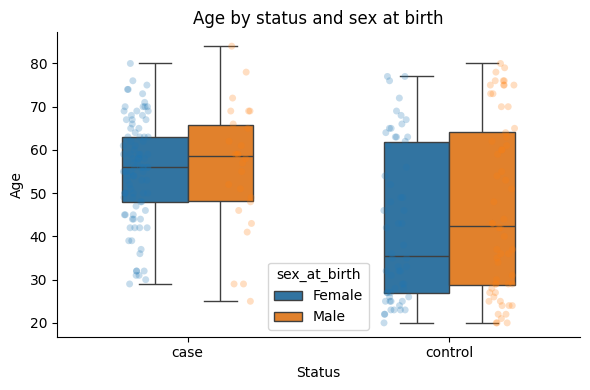

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(
    data=stenosis_for_eda,
    x="status", y="age", hue="sex_at_birth",
    ax=ax, width=0.5,
)
sns.stripplot(
    data=stenosis_for_eda,
    x="status", y="age", hue="sex_at_birth",
    dodge=True, alpha=0.25, ax=ax,
    legend=False,
)
ax.set_title("Age by status and sex at birth")
ax.set_xlabel("Status")
ax.set_ylabel("Age")
sns.despine()
plt.tight_layout()
plt.show()

NameError: name 'stenosis_cohort_features' is not defined

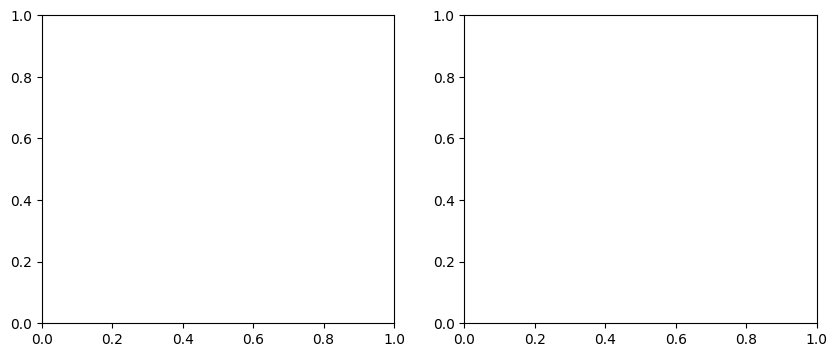

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, feature, title in zip(
    axes,
    ["local_jitter", "local_shimmer"],
    ["Jitter", "Shimmer"],
):
    plot_df = (
        stenosis_cohort_features
        [["participant_id", "status", "sex_at_birth", feature]]
        .dropna(subset=["sex_at_birth"])
    )
    sns.boxplot(data=plot_df, x="status", y=feature, hue="sex_at_birth", ax=ax, width=0.5)
    sns.stripplot(
        data=plot_df, x="status", y=feature, hue="sex_at_birth",
        dodge=True, alpha=0.25, ax=ax, legend=False,
    )
    ax.set_title(title)
    ax.set_xlabel("Status")
    ax.set_ylabel(feature)

sns.despine()
plt.tight_layout()
plt.show()